# Multi-Scale Patch Thresholding for ARCADE

Idea: split each raw angiogram into non-overlapping `Z x Z` patches and, per patch,
threshold at the **midrange** (`(local_min + local_max) / 2`) of that patch --
pixels darker than the local midrange are vessel (output `0`), pixels lighter are
background (output `255`). This is a classic local-adaptive threshold: because the
threshold is computed *within* each patch, it self-corrects for slow illumination/
contrast drift across the frame that a single global threshold can't handle.

The catch: patch size trades off two failure modes.
- **Small `Z`** (e.g. 6): threshold adapts almost pixel-by-pixel, so it tracks fine
  boundary detail well, but a patch that happens to contain no real contrast (pure
  background, or pure vessel interior) has a near-zero min/max gap and its
  threshold decision becomes noise-dominated.
- **Large `Z`** (e.g. 32+): threshold is stable and well-conditioned (each patch
  almost certainly spans both some background and some vessel), but a single
  threshold is applied across a region large enough that the *true* local
  brightness can drift within the patch, so fine boundaries get rounded off / lost.

So: run several patch sizes, and combine their per-scale binary maps into one
output. The open question -- the point of this notebook -- is **how much weight
each scale should get**. Below: a fully vectorized, scale-agnostic implementation
(add/remove patch sizes freely in `PATCH_SIZES`), a couple of starting-guess
weighting strategies, visual previews, and a quantitative sweep against ground
truth (`labelsTs`) to actually measure which strategy segments vessels best --
used here purely as an offline oracle to compare classical-CV preprocessing
strategies, not for training anything.

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

REPO_ROOT = Path.cwd()
if (REPO_ROOT / "lightm-unet").exists():
    pass
elif (REPO_ROOT.parent / "lightm-unet").exists():
    REPO_ROOT = REPO_ROOT.parent

DATASET_DIR = REPO_ROOT / "data" / "nnUNet_raw" / "Dataset501_ARCADE"
IMAGES_TS_DIR = DATASET_DIR / "imagesTs"
LABELS_TS_DIR = DATASET_DIR / "labelsTs"
IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

# --- The one thing this whole notebook is about tuning: which scales, and how
# much each contributes. Add/remove entries freely -- everything below is scale-
# count-agnostic.
PATCH_SIZES: list[int] = [6, 16, 32, 64]

N_PREVIEW = 4          # how many sample images to visualize below
N_EVAL = 60            # how many test cases to score each strategy against (300 = full set, slower)

# Gabor filter bank (see "Gabor filter response" section below): wavelength =
# 1/frequency, so 0.1 => ~10px wavelength, matching the median vessel width
# measured on ARCADE GT (~8-10px; see cldice.py docstring). n_orientations=6
# spans 0..150deg in 30deg steps (a Gabor kernel at theta and theta+180deg is
# identical, so full 0..180deg coverage does not need more than that without
# finer angular resolution). Runtime is dominated by kernel size, which grows
# as roughly 1/frequency^2 -- 0.1 is already ~1.5s/image at 6 orientations;
# going much below ~0.07 gets noticeably slower.
GABOR_FREQUENCY = 0.1
GABOR_N_ORIENTATIONS = 6

print("Repo root   :", REPO_ROOT)
print("ImagesTs    :", IMAGES_TS_DIR)
print("LabelsTs    :", LABELS_TS_DIR)
print("Patch sizes :", PATCH_SIZES)

Repo root   : C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet
ImagesTs    : C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\data\nnUNet_raw\Dataset501_ARCADE\imagesTs
LabelsTs    : C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\data\nnUNet_raw\Dataset501_ARCADE\labelsTs
Patch sizes : [6, 16, 32, 64]


In [2]:
# Build the sample index: match imagesTs frames to labelsTs ground truth (used only
# for scoring/preview, never for computing the thresholded output itself).
def case_id_from_image(path: Path) -> str:
    stem = path.stem
    return stem[:-5] if stem.endswith("_0000") else stem


def image_files(folder: Path) -> list[Path]:
    return sorted(p for p in folder.iterdir() if p.suffix.lower() in IMG_EXTS)


gt_files = {p.stem: p for p in image_files(LABELS_TS_DIR)} if LABELS_TS_DIR.exists() else {}
samples = []
for img in image_files(IMAGES_TS_DIR):
    cid = case_id_from_image(img)
    samples.append({"case_id": cid, "image": img, "gt": gt_files.get(cid)})

print(f"Found {len(samples)} imagesTs frames, {sum(s['gt'] is not None for s in samples)} with matching GT")


def load_gray(path: Path) -> np.ndarray:
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32)


def load_gt(path: Path) -> np.ndarray:
    arr = np.asarray(Image.open(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr

Found 300 imagesTs frames, 300 with matching GT


## Core algorithm: per-scale midrange thresholding

`block_stats` computes the local min/max over non-overlapping `Z x Z` blocks (image
edge-padded so any size divides evenly) and upsamples them back to full resolution --
fully vectorized via `reshape`, no per-pixel Python loop, so this stays fast even
run over many scales x many images.

In [3]:
def block_stats(img: np.ndarray, z: int) -> tuple[np.ndarray, np.ndarray]:
    """Per-pixel local (min, max) over non-overlapping z x z blocks, upsampled
    (nearest-neighbor repeat) back to img's original resolution. Edge-padded so
    H/W need not be divisible by z."""
    h, w = img.shape
    pad_h, pad_w = (-h) % z, (-w) % z
    padded = np.pad(img, ((0, pad_h), (0, pad_w)), mode="edge")
    ph, pw = padded.shape
    blocks = padded.reshape(ph // z, z, pw // z, z)
    block_min = blocks.min(axis=(1, 3))
    block_max = blocks.max(axis=(1, 3))
    min_full = np.repeat(np.repeat(block_min, z, axis=0), z, axis=1)[:h, :w]
    max_full = np.repeat(np.repeat(block_max, z, axis=0), z, axis=1)[:h, :w]
    return min_full, max_full


def patch_threshold(img: np.ndarray, z: int) -> dict:
    """One scale's local midrange threshold. Vessels are darker than surrounding
    tissue in these angiograms, so below-threshold pixels are vessel (0),
    at-or-above is background (255)."""
    min_full, max_full = block_stats(img, z)
    threshold = (min_full + max_full) / 2.0
    contrast = max_full - min_full  # local min/max gap: low = low-confidence patch
    vessel = img < threshold
    binary = np.where(vessel, 0, 255).astype(np.uint8)
    return {"binary": binary, "threshold": threshold, "contrast": contrast}


def all_scales(img: np.ndarray, patch_sizes: list[int] = PATCH_SIZES) -> dict[int, dict]:
    return {z: patch_threshold(img, z) for z in patch_sizes}

## Combining scales

Two starting strategies for "how much should each patch size contribute":

1. **Fixed per-scale weights** -- a single scalar weight per `Z`, the same
   everywhere in the image. Simplest possible guess: equal weights. Also tried
   below: weight `\propto 1/Z` (favor fine detail) and weight `\propto Z` (favor
   stable/coarse decisions).
2. **Contrast-weighted (adaptive, no manual weight at all)** -- at every pixel,
   weight each scale's vote by that scale's *local contrast* (`max - min`) at that
   location, normalized across scales. A scale that had almost no contrast to work
   with at this particular spot (e.g. a 6x6 patch sitting entirely inside a big
   flat vessel interior) is automatically down-weighted there, while a scale with
   a clean local min/max split dominates -- self-tuning per pixel rather than one
   global scalar per scale.

In [4]:
def combine_fixed(results: dict[int, dict], weights: dict[int, float] | None = None) -> np.ndarray:
    """Weighted sum of each scale's binary (0/255) map -> continuous [0, 255] map
    (higher = more scale-weighted votes for 'background'). weights=None -> equal."""
    zs = list(results.keys())
    if weights is None:
        weights = {z: 1.0 for z in zs}
    wsum = sum(weights[z] for z in zs)
    acc = np.zeros_like(next(iter(results.values()))["binary"], dtype=np.float32)
    for z in zs:
        acc += weights[z] * results[z]["binary"].astype(np.float32)
    return acc / wsum


def combine_contrast_weighted(results: dict[int, dict], eps: float = 1e-3) -> np.ndarray:
    """Per-pixel adaptive combination: each scale's vote is weighted by its own
    local contrast at that pixel, normalized across scales."""
    zs = list(results.keys())
    contrasts = np.stack([results[z]["contrast"] for z in zs], axis=0)  # (n_scales, H, W)
    binaries = np.stack([results[z]["binary"].astype(np.float32) for z in zs], axis=0)
    w = contrasts + eps
    w_norm = w / w.sum(axis=0, keepdims=True)
    return (w_norm * binaries).sum(axis=0)


def binarize(combined: np.ndarray, cutoff: float = 127.5) -> np.ndarray:
    """Continuous combined map -> hard vessel/background mask (True = vessel)."""
    return combined < cutoff


# A first guess at named strategies to compare -- add your own freely.
def strategy_weights(name: str, patch_sizes: list[int]) -> dict[int, float] | None:
    if name == "equal":
        return {z: 1.0 for z in patch_sizes}
    if name == "prefer_fine":
        return {z: 1.0 / z for z in patch_sizes}
    if name == "prefer_coarse":
        return {z: float(z) for z in patch_sizes}
    raise ValueError(f"Unknown fixed-weight strategy: {name}")

## Gabor filter response

A different kind of local descriptor: rather than thresholding intensity, a bank of Gabor filters at several orientations responds to oriented, elongated structure -- exactly the shape a vessel segment has (as opposed to isotropic blobs or the axis-aligned grid artifacts the block thresholding above produces). At each pixel we take the max response magnitude across all orientations tried, so the result highlights edges/ridges regardless of which way they run.

Shown below on two different inputs: the raw grayscale frame (does Gabor alone pick out the vessel tree from a photographic image), and the `prefer_fine` combined threshold map (does Gabor help suppress the blocky/speckle noise from small-patch thresholding, since block-grid edges are axis-aligned while vessels run at many angles).

In [5]:
from skimage.filters import gabor


def gabor_response(img: np.ndarray, frequency: float = GABOR_FREQUENCY,
                    n_orientations: int = GABOR_N_ORIENTATIONS) -> np.ndarray:
    """Multi-orientation Gabor filter bank: max response magnitude across
    orientations at each pixel. img is expected normalized to [0, 1]."""
    responses = []
    for i in range(n_orientations):
        theta = i * np.pi / n_orientations
        real, imag = gabor(img, frequency=frequency, theta=theta)
        responses.append(np.hypot(real, imag))
    return np.max(np.stack(responses, axis=0), axis=0)


def normalize01(img: np.ndarray) -> np.ndarray:
    return img.astype(np.float32) / 255.0 if img.max() > 1.5 else img.astype(np.float32)


## Preview: raw image, per-scale maps, and combined outputs

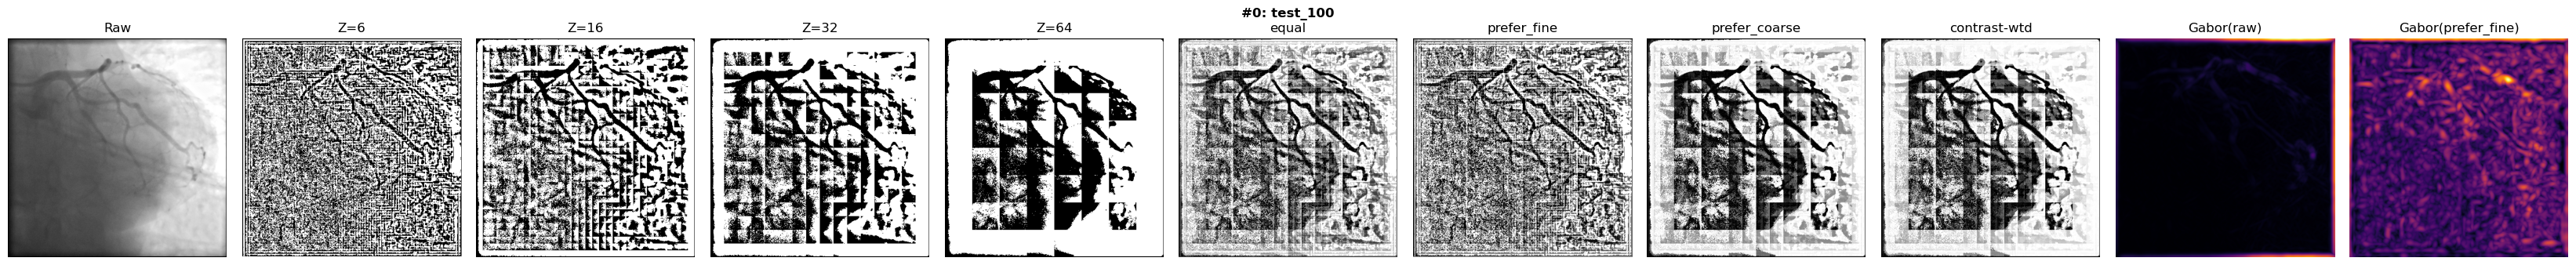

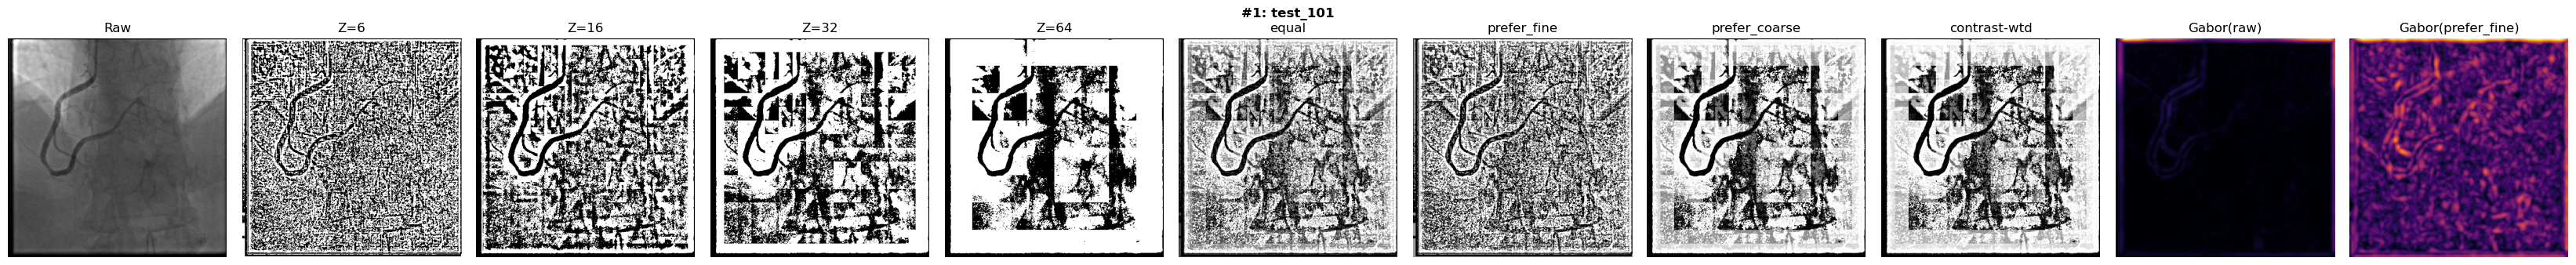

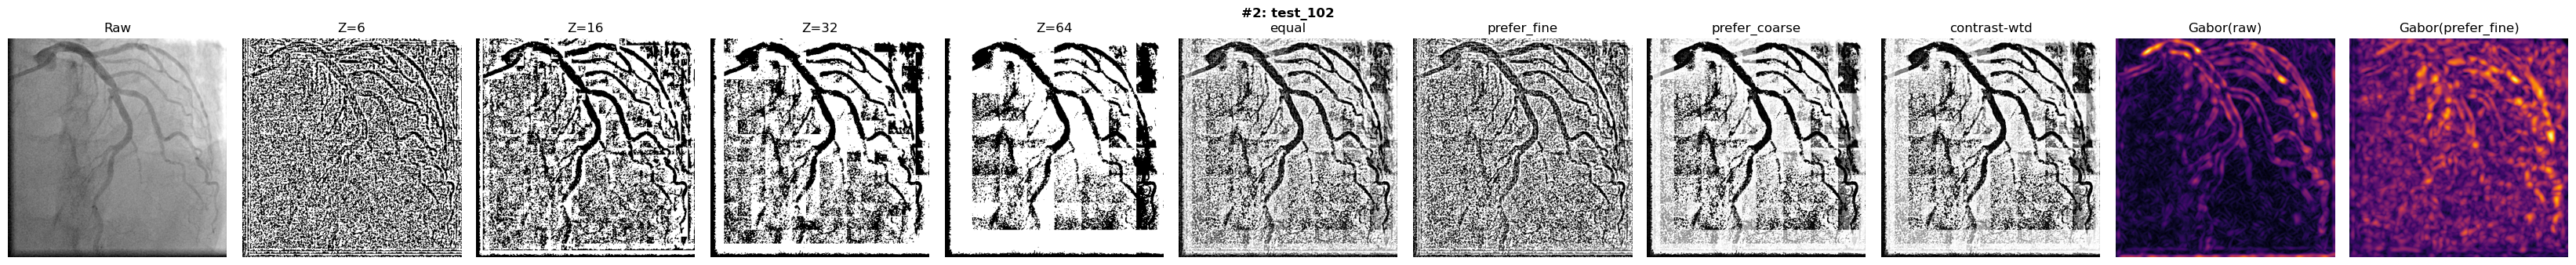

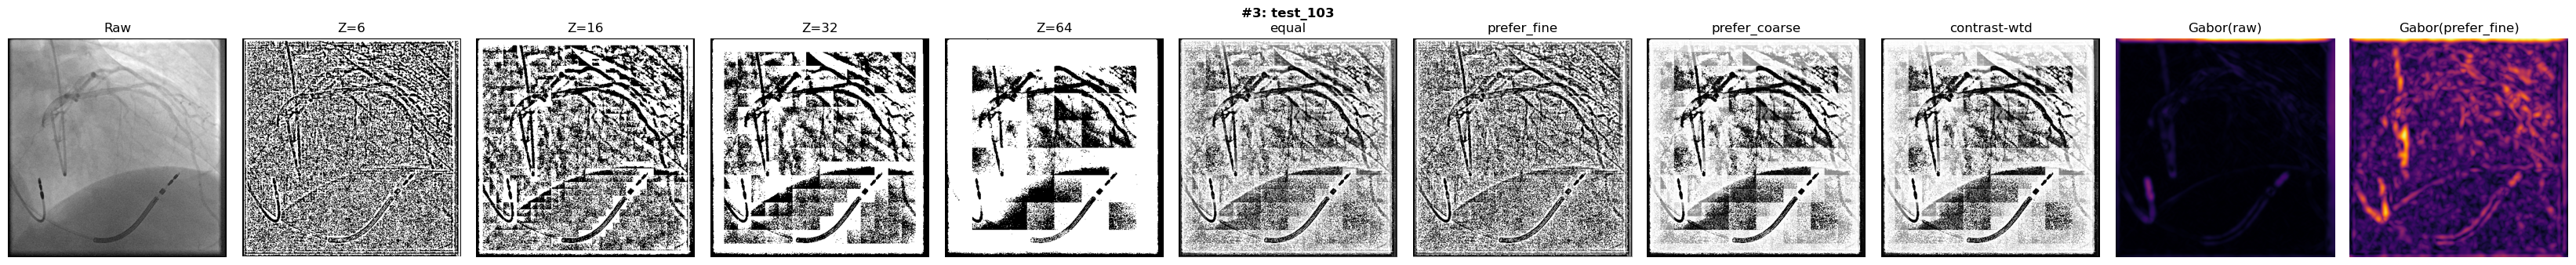

In [6]:
def preview_case(idx: int, patch_sizes: list[int] = PATCH_SIZES, save_path: Path | None = None):
    item = samples[idx]
    img = load_gray(item["image"])
    results = all_scales(img, patch_sizes)

    combined_equal = combine_fixed(results, strategy_weights("equal", patch_sizes))
    combined_fine = combine_fixed(results, strategy_weights("prefer_fine", patch_sizes))
    combined_coarse = combine_fixed(results, strategy_weights("prefer_coarse", patch_sizes))
    combined_contrast = combine_contrast_weighted(results)

    gabor_raw = gabor_response(normalize01(img))
    gabor_prefer_fine = gabor_response(normalize01(combined_fine))

    n_cols = 1 + len(patch_sizes) + 4 + 2  # raw + per-scale + 4 combinations + 2 gabor views
    fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 3.4))

    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Raw")
    axes[0].axis("off")

    for i, z in enumerate(patch_sizes):
        axes[1 + i].imshow(results[z]["binary"], cmap="gray", vmin=0, vmax=255)
        axes[1 + i].set_title(f"Z={z}")
        axes[1 + i].axis("off")

    combos = [
        ("equal", combined_equal), ("prefer_fine", combined_fine),
        ("prefer_coarse", combined_coarse), ("contrast-wtd", combined_contrast),
    ]
    for j, (name, combo) in enumerate(combos):
        col = 1 + len(patch_sizes) + j
        axes[col].imshow(combo, cmap="gray", vmin=0, vmax=255)
        axes[col].set_title(name)
        axes[col].axis("off")

    gabor_views = [("Gabor(raw)", gabor_raw), ("Gabor(prefer_fine)", gabor_prefer_fine)]
    for k, (name, resp) in enumerate(gabor_views):
        col = 1 + len(patch_sizes) + len(combos) + k
        axes[col].imshow(resp, cmap="inferno")
        axes[col].set_title(name)
        axes[col].axis("off")

    fig.suptitle(f"#{idx}: {item['case_id']}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()


for i in range(min(N_PREVIEW, len(samples))):
    preview_case(i)

## Quantifying which weighting actually works best

Visual inspection only goes so far. Since ground truth exists for the test set,
score each candidate strategy's hard vessel/background call against `labelsTs`
(`gt > 0`) -- this uses GT purely as an offline oracle to compare classical-CV
preprocessing strategies against each other, not to train or fit anything.
Includes each single scale alone as a baseline, so you can see whether combining
scales actually beats the best individual one.

In [7]:
EPS = 1e-8


def dice_precision_recall(pred_vessel: np.ndarray, gt_vessel: np.ndarray) -> tuple[float, float, float]:
    tp = int((pred_vessel & gt_vessel).sum())
    fp = int((pred_vessel & ~gt_vessel).sum())
    fn = int((~pred_vessel & gt_vessel).sum())
    dice = (2 * tp) / (2 * tp + fp + fn + EPS)
    precision = tp / (tp + fp + EPS)
    recall = tp / (tp + fn + EPS)
    return dice, precision, recall


eval_samples = [s for s in samples if s["gt"] is not None][:N_EVAL]
print(f"Scoring {len(eval_samples)} cases")

strategy_names = ["equal", "prefer_fine", "prefer_coarse", "contrast"] + [f"only_{z}" for z in PATCH_SIZES]
counts = {name: {"tp": 0, "fp": 0, "fn": 0} for name in strategy_names}

for item in eval_samples:
    img = load_gray(item["image"])
    gt = load_gt(item["gt"])
    gt = gt if gt.shape == img.shape else np.asarray(
        Image.fromarray(gt).resize((img.shape[1], img.shape[0]), Image.NEAREST)
    )
    gt_vessel = gt > 0
    results = all_scales(img, PATCH_SIZES)

    candidates = {
        "equal": combine_fixed(results, strategy_weights("equal", PATCH_SIZES)),
        "prefer_fine": combine_fixed(results, strategy_weights("prefer_fine", PATCH_SIZES)),
        "prefer_coarse": combine_fixed(results, strategy_weights("prefer_coarse", PATCH_SIZES)),
        "contrast": combine_contrast_weighted(results),
    }
    for z in PATCH_SIZES:
        candidates[f"only_{z}"] = results[z]["binary"].astype(np.float32)

    for name, combo in candidates.items():
        pred_vessel = binarize(combo)
        tp = int((pred_vessel & gt_vessel).sum())
        fp = int((pred_vessel & ~gt_vessel).sum())
        fn = int((~pred_vessel & gt_vessel).sum())
        counts[name]["tp"] += tp
        counts[name]["fp"] += fp
        counts[name]["fn"] += fn

rows = []
for name, c in counts.items():
    dice = (2 * c["tp"]) / (2 * c["tp"] + c["fp"] + c["fn"] + EPS)
    precision = c["tp"] / (c["tp"] + c["fp"] + EPS)
    recall = c["tp"] / (c["tp"] + c["fn"] + EPS)
    rows.append({"strategy": name, "dice": dice, "precision": precision, "recall": recall})

ranking = pd.DataFrame(rows).sort_values("dice", ascending=False, ignore_index=True)
print(f"Pooled dice/precision/recall vs. GT foreground, {len(eval_samples)} cases, patch sizes {PATCH_SIZES}")
display(ranking)

Scoring 60 cases


Pooled dice/precision/recall vs. GT foreground, 60 cases, patch sizes [6, 16, 32, 64]


,strategy,dice,precision,recall
0,contrast,0.151979,0.084403,0.762299
1,prefer_coarse,0.149009,0.082777,0.745557
2,only_64,0.149009,0.082777,0.745557
3,equal,0.145441,0.080706,0.734921
4,only_32,0.126479,0.068782,0.784793
5,only_16,0.110076,0.059153,0.791198
6,prefer_fine,0.086197,0.046138,0.654131
7,only_6,0.086197,0.046138,0.654131


## Notes / next steps

- This is a **classical thresholding baseline**, not a learned segmentation --
  expect its dice to be well below any of the trained models in `analysis/`.
  The point is to find the best-performing preprocessing map, then decide how to
  use it (e.g. as an extra input channel to the network, or as a prior for
  postprocessing) -- both open beyond this notebook.
- **Blockiness**: non-overlapping patches produce visible grid artifacts at each
  scale's boundary. If that matters, switch `block_stats` to a sliding-window
  min/max (`scipy.ndimage.minimum_filter`/`maximum_filter` with size=`z`) instead
  of the reshape-based non-overlapping version -- same interface, smoother output,
  more compute.
- **Midrange vs. true mean**: this uses `(min+max)/2` per block (matches "mean
  thresholding ... to two values min and max"). A true arithmetic mean
  (`blocks.mean(axis=(1,3))`) or Otsu-per-block are easy one-line swaps in
  `patch_threshold` if midrange turns out to be too sensitive to single-pixel
  outliers (min/max are, by construction, the least robust statistics available).
- **Weighting strategies actually tried here are guesses**, per the brief -- treat
  the ranking table as a starting point, not a final answer. Natural extensions:
  a learned per-scale weight (fit the scalar weights, or even a tiny per-pixel
  gating conv, against the dice objective above instead of hand-picking them);
  restricting `only_Z` / combination scoring to just the LAD/LCX or RCA territory
  to see if the best scale differs by vessel width (RCA runs wider than LAD/LCX,
  per the vessel-width numbers in `lightm-unet/.../loss/cldice.py`'s docstring).
- `N_EVAL` is capped at 60 for a fast first pass -- set to `len(samples)` (300)
  for the real number once a shortlist of strategies looks worth trusting.